In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.ndimage import binary_erosion, binary_dilation

In [2]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [4]:
lati1,lati2=-5,-16
R_X = xr.open_dataset('Rossby_radius_and_X.nc').lat; step = R_X.sel(lat=slice(lati2,lati1)).shape[0]
step

134

In [5]:
# ============================================================
# 1. Load wind data and CROCO grid
# ============================================================
winds_ds = xr.open_dataset('winds_NHUS.nc').compute()

ds = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc',
                     chunks={'time': 1})

mask     = ds['mask_rho'].values     # 1=ocean, 0=land
lon_grid = ds['lon_rho'].values      # 2D
lat_grid = ds['lat_rho'].values      # 2D

# ============================================================
# 2. Extract coastal points (easternmost ocean cell per row)
# ============================================================
coast_lon_list = []
coast_lat_list = []

for j in range(mask.shape[0]):
    row = mask[j, :]
    ocean_cols = np.where(row == 1)[0]
    if len(ocean_cols) == 0:
        continue
    i = ocean_cols[-1]
    coast_lon_list.append(lon_grid[j, i])
    coast_lat_list.append(lat_grid[j, i])

coast_lon_all = np.array(coast_lon_list)
coast_lat_all = np.array(coast_lat_list)

# Filter to 5°S–16°S
domain = (coast_lat_all >= lati2) & (coast_lat_all <= lati1)
coast = {
    'lat': coast_lat_all[domain],
    'lon': coast_lon_all[domain],
}
print(f"Coastal points in 5°S–16°S: {len(coast['lat'])}")

# ============================================================
# 3. Extract coastal strips (n cells offshore per coastal point)
# ============================================================
lat = winds_ds.lat.values     # 1D
lon = winds_ds.lon.values     # 1D
u   = winds_ds.u10.values     # (time, lat, lon)
v   = winds_ds.v10.values

n = 10
lonc = np.empty((len(coast['lat']), n))
latc = np.empty((len(coast['lat']), n))
uc   = np.empty((u.shape[0], len(coast['lat']), n))
vc   = np.empty((v.shape[0], len(coast['lat']), n))

for point_idx, (lat_val, lon_val) in enumerate(zip(coast['lat'], coast['lon'])):
    lat_idx = np.abs(lat - lat_val).argmin()
    lon_idx = np.abs(lon - lon_val).argmin()
    uc[:, point_idx, :]  = u[:, lat_idx, int(lon_idx-n):int(lon_idx)]
    vc[:, point_idx, :]  = v[:, lat_idx, int(lon_idx-n):int(lon_idx)]
    lonc[point_idx, :]   = lon[int(lon_idx-n):int(lon_idx)]
    latc[point_idx, :]   = lat[lat_idx]

uc[np.abs(uc) > 100] = np.nan
vc[np.abs(vc) > 100] = np.nan

# ============================================================
# 4. Local coastline bearing
# ============================================================
def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1_rad = np.deg2rad(lat1)
    lat2_rad = np.deg2rad(lat2)
    lon1_rad = np.deg2rad(lon1)
    lon2_rad = np.deg2rad(lon2)

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    x = delta_lon * np.cos((lat1_rad + lat2_rad) / 2)
    y = delta_lat

    bearing_rad = np.arctan2(y, x)
    bearing_deg = (np.rad2deg(bearing_rad) + 360) % 360
    return bearing_deg


point_num = len(coast['lat'])
coast_orientation = np.empty(point_num)

for i in range(point_num):
    if i < point_num - 1:
        lat1 = coast['lat'][i]
        lon1 = coast['lon'][i]
        lat2 = coast['lat'][i+1]
        lon2 = coast['lon'][i+1]
    else:
        lat1 = coast['lat'][i-1]
        lon1 = coast['lon'][i-1]
        lat2 = coast['lat'][i]
        lon2 = coast['lon'][i]

    coast_orientation[i] = calculate_bearing(lat1, lon1, lat2, lon2)

# ============================================================
# 5. Project winds onto local along-coast unit vector
# ============================================================
coast_orientation_rad = np.deg2rad(coast_orientation)
u_alongshore_unit = np.cos(coast_orientation_rad).reshape(1, point_num, 1)
v_alongshore_unit = np.sin(coast_orientation_rad).reshape(1, point_num, 1)
wind_alongshore = uc * u_alongshore_unit + vc * v_alongshore_unit  # (time, coast, n)

# ============================================================
# 6. Distances from each coastal point to its strip cells
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1_rad = np.deg2rad(lat1)
    lon1_rad = np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)
    lon2_rad = np.deg2rad(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (np.sin(delta_lat / 2.0) ** 2
         + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


coast_lon_arr = np.array(coast['lon'])
coast_lat_arr = np.array(coast['lat'])
coast_lon_expanded = coast_lon_arr[:, np.newaxis]
coast_lat_expanded = coast_lat_arr[:, np.newaxis]

distances = haversine(coast_lat_expanded, coast_lon_expanded, latc, lonc)  # (coast, n)

# ============================================================
# 7. Ekman transport and pumping
# ============================================================
rhoa  = 1.22
cd    = 0.0013
rho   = 1025.0
omega = 7.2921e-5

f = 2 * omega * np.sin(np.deg2rad(latc))                          # (coast, n)
windspeed = np.sqrt(uc**2 + vc**2)                                # (time, coast, n)

#Uekman cross-shore
U_ek_cross = -rhoa * cd * windspeed * wind_alongshore / (rho * f)
# Ekman transport (m^2/s if you remove distances; her version normalizes by distance)
etransport = -rhoa * cd * windspeed * wind_alongshore / (rho * f * distances)

# Ekman pumping
epumping = np.zeros_like(uc)
dy = 111000.0 * (lat[1] - lat[0])  # scalar (m)
dv_dx = np.zeros_like(uc)

for j in range(step): #latitude
    x_j = 111000.0 * np.cos(np.radians(lat[j])) * (lon[1] - lon[0]) 
    epumping[:,j,:] = (rhoa * cd * windspeed[:,j,:] / (rho)) * (np.gradient(vc[:, j, :]/f[j], x_j, axis=-1) - np.gradient(uc[:,j,:]/f[j], dy, axis=1))

# ============================================================
# 8. Ekman layer depth
# ============================================================

# latitude in radians
lat_rad = np.deg2rad(latc)   # (coast, n)

# avoid division by zero near equator
sinlat = np.sin(lat_rad)
sinlat_abs = np.abs(sinlat)

# optional: avoid extremely small values (numerical stability)
sinlat_abs[sinlat_abs < 1e-6] = np.nan

# Ekman depth (meters)
DE = 4.3 * windspeed / np.sqrt(sinlat_abs)   # (time, coast, n)

Coastal points in 5°S–16°S: 134


In [6]:
# ============================================================
# 9. Wrap into xarray
# ============================================================
out = xr.Dataset(
    data_vars={
        'wind_alongshore': (('time', 'coast_point', 'offshore'), wind_alongshore),
        'tau_alongshore':  (('time', 'coast_point', 'offshore'), rhoa * cd * windspeed * wind_alongshore),
        'etransport':      (('time', 'coast_point', 'offshore'), etransport),
        'epumping':        (('time', 'coast_point', 'offshore'), epumping),
        'Ek_layer_D':      (('time','coast_point','offshore'), DE),
    },
    coords={
        'time':        winds_ds.time,
        'coast_point': np.arange(point_num),
        'offshore':    np.arange(n),
        'lat':         (('coast_point', 'offshore'), latc),
        'lon':         (('coast_point', 'offshore'), lonc),
        'bearing':     ('coast_point', coast_orientation),
        'distance':    (('coast_point', 'offshore'), distances),
        'f':           (('coast_point', 'offshore'), f),
    },
    attrs={'description': 'Alongshore winds, Ekman transport and pumping (NHUS, 5°S–16°S)'},
)

out['wind_alongshore'].attrs = {'units': 'm/s',  'long_name': 'Alongshore wind component'}
out['tau_alongshore'].attrs  = {'units': 'N/m^2','long_name': 'Alongshore wind stress'}
out['etransport'].attrs      = {'units': 'm/s',  'long_name': 'Ekman transport (normalized by distance)'}
out['epumping'].attrs        = {'units': 'm/s',  'long_name': 'Ekman pumping'}
out['U_ek_cross'] = (('time', 'coast_point', 'offshore'), U_ek_cross)
out['U_ek_cross'].attrs = {'units': 'm^2/s',
                            'long_name': 'Cross-shore Ekman transport (BUI)'}
print(out)

<xarray.Dataset> Size: 28MB
Dimensions:          (time: 432, coast_point: 134, offshore: 10)
Coordinates:
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
  * coast_point      (coast_point) int64 1kB 0 1 2 3 4 5 ... 129 130 131 132 133
  * offshore         (offshore) int64 80B 0 1 2 3 4 5 6 7 8 9
    lat              (coast_point, offshore) float64 11kB -15.95 ... -5.076
    lon              (coast_point, offshore) float64 11kB -75.03 ... -81.28
    bearing          (coast_point) float64 1kB 135.0 161.6 135.0 ... 90.0 90.0
    distance         (coast_point, offshore) float64 11kB 8.909e+04 ... 9.23e+03
    f                (coast_point, offshore) float64 11kB -4.009e-05 ... -1.2...
Data variables:
    wind_alongshore  (time, coast_point, offshore) float64 5MB 5.965 ... 5.872
    tau_alongshore   (time, coast_point, offshore) float64 5MB 0.05675 ... 0....
    etransport       (time, coast_point, offshore) float64 5MB 1.55e-05 ... 0...
    epumping         (time, 

/tmp/ipykernel_3940758/1209536511.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(out.lon, out.lat, da.values, shading='auto', cmap='RdBu_r')


Text(0.5, 1.0, '1980-01-31')

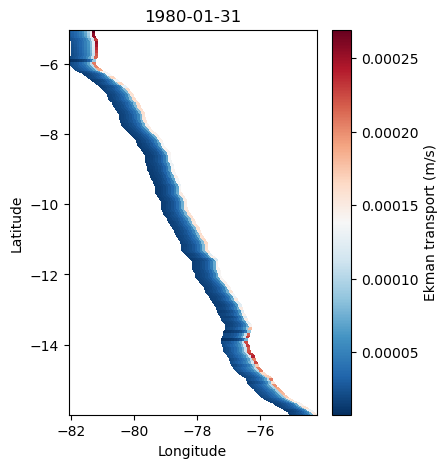

In [7]:
import matplotlib.pyplot as plt

da = out.etransport.isel(time=0)

fig, ax = plt.subplots(figsize=(4, 5))
pc = ax.pcolormesh(out.lon, out.lat, da.values, shading='auto', cmap='RdBu_r')
plt.colorbar(pc, label='Ekman transport (m/s)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'{str(da.time.values)[:10]}')

Text(0.5, 1.0, 'Ekman transport')

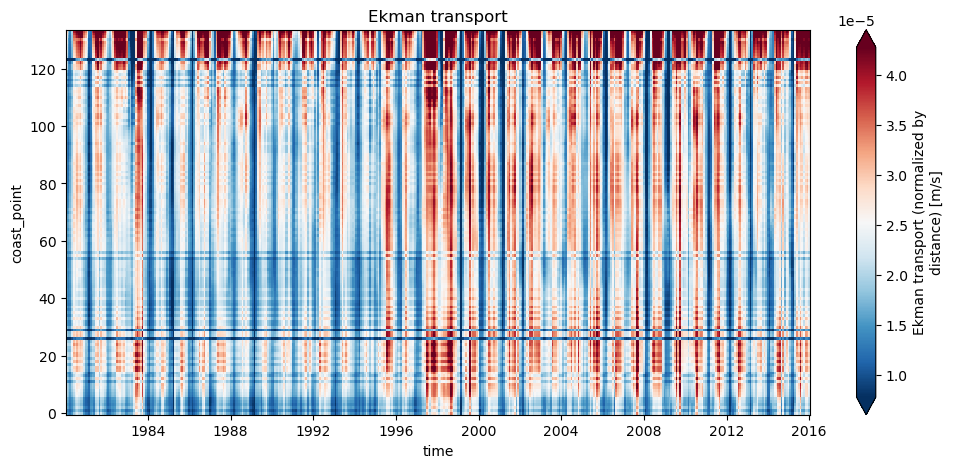

In [8]:
hov = out.etransport.isel(offshore=0)   # (time, coast_point)
hov = hov.assign_coords(coast_lat=('coast_point', out.lat.isel(offshore=0).values))

fig, ax = plt.subplots(figsize=(12, 5))
hov.plot(x='time', y='coast_point', cmap='RdBu_r', robust=True, ax=ax)
ax.set_title('Ekman transport')

Text(0, 0.5, 'Latitude')

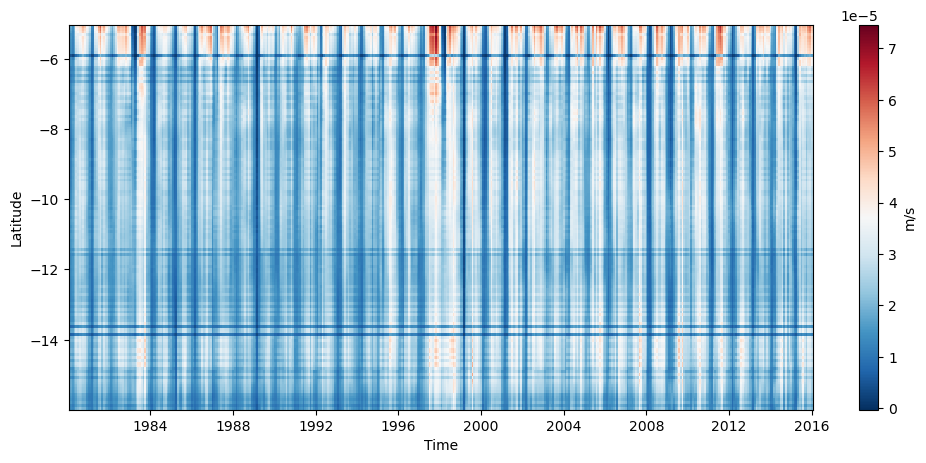

In [9]:
plt.figure(figsize=(12, 5))
plt.pcolormesh(
    out.time.values,
    out.lat.isel(offshore=0).values,   # 1D latitude per coast point
    hov.transpose('coast_point', 'time').values,
    shading='auto', cmap='RdBu_r'
)
plt.colorbar(label='m/s')
plt.xlabel('Time')
plt.ylabel('Latitude')

In [12]:
wmld = xr.open_dataset('W_mld_Croco.nc')
mask = coastal_band_mask(wmld, 'WMLD', 111)

wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(lati2,lati1))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

In [13]:
d = (1/12)*10*111*1000

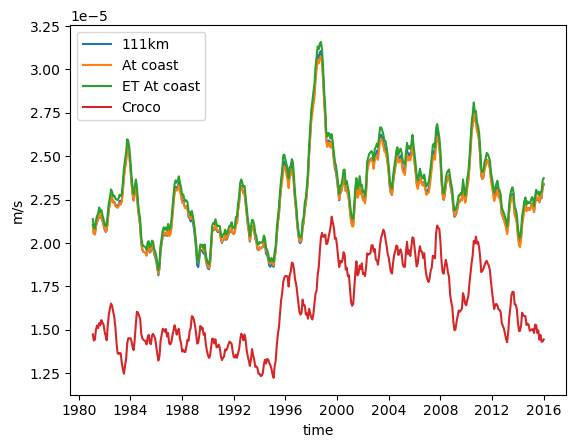

In [14]:
(out.U_ek_cross/d).isel(offshore=0).mean('coast_point').rename('m2/s').rolling(time=13).mean().plot(label='111km')
(out.U_ek_cross/d).isel(offshore=9).mean('coast_point').rename('m2/s').rolling(time=13).mean().plot(label='At coast')
(out.etransport).isel(offshore=0).mean('coast_point').rename('m2/s').rolling(time=13).mean().plot(label='ET At coast')
wmld.WMLD.mean(dim=('lat','lon')).rolling(time=13).mean().rename('m/s').plot(label='Croco')

plt.legend()

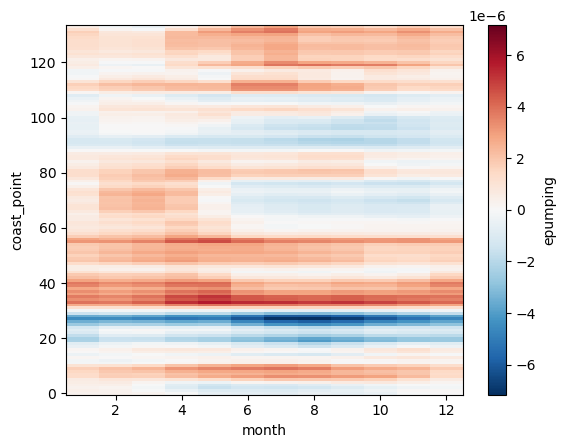

In [15]:
seasonality(out.epumping.mean('offshore')).plot(x='month')

/tmp/ipykernel_3940758/3097970237.py:4: UserWarning: The following kwargs were not used by contour: 'shading'
  plt.contourf(


Text(0, 0.5, 'Latitude')

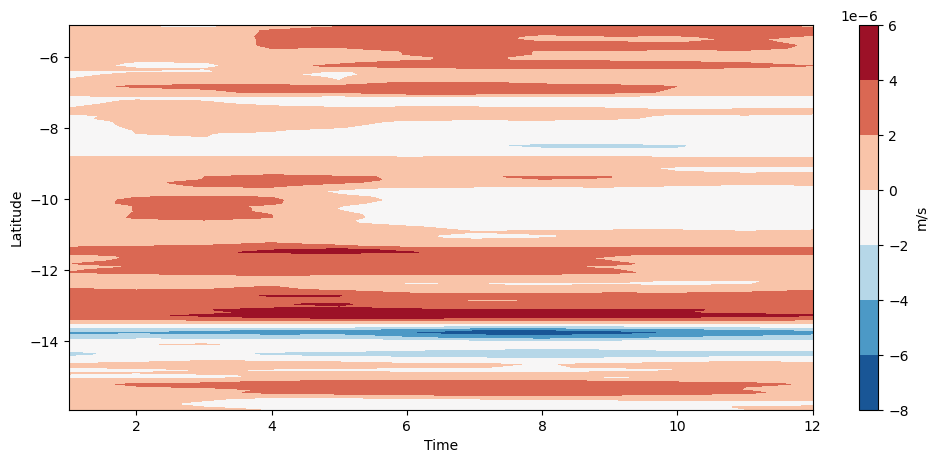

In [16]:
hov = seasonality(out.epumping).mean('offshore')  

plt.figure(figsize=(12, 5))
plt.contourf(
    hov.month.values,
    out.lat.isel(offshore=0).values,   # 1D latitude per coast point
    hov.transpose('coast_point', 'month').values,
    shading='auto', cmap='RdBu_r'
)
plt.colorbar(label='m/s')
plt.xlabel('Time')
plt.ylabel('Latitude')

In [17]:
# out.to_netcdf('Winds_components_Lu.nc')

## Ekman layer depth

In [19]:
MLD = xr.open_dataset('MLD.nc').compute()

In [20]:
mask = coastal_band_mask(MLD,'MLD',111).sel(lon=slice(-85,None),lat=slice(lati2,lati1)) 
MLD = MLD.where(mask).MLD

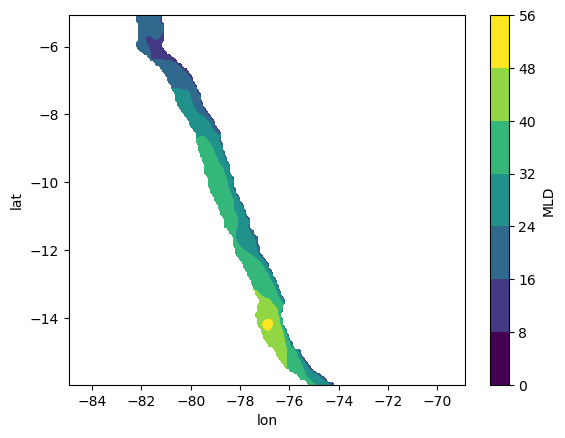

In [21]:
MLD.mean('time').plot.contourf()

/tmp/ipykernel_3940758/3375519385.py:5: UserWarning: The following kwargs were not used by contour: 'shading'
  pc = ax[0].contourf(out.lon, out.lat, da.values, shading='auto', cmap='viridis')


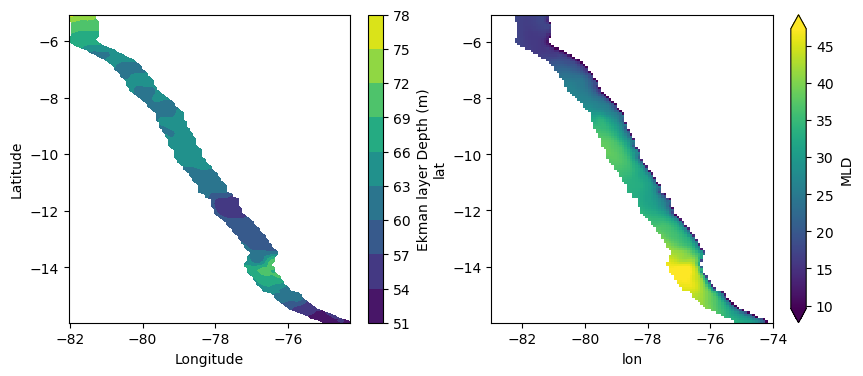

In [22]:
da = out.Ek_layer_D.mean('time')

fig, ax = plt.subplots(1,2,figsize=(10, 4))

pc = ax[0].contourf(out.lon, out.lat, da.values, shading='auto', cmap='viridis')
plt.colorbar(pc, label='Ekman layer Depth (m)')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')

MLD.mean('time').sel(lon=slice(-83,-74)).plot(ax=ax[1],robust=True)
# ax.set_title(f'{str(da.time.values)[:10]}')

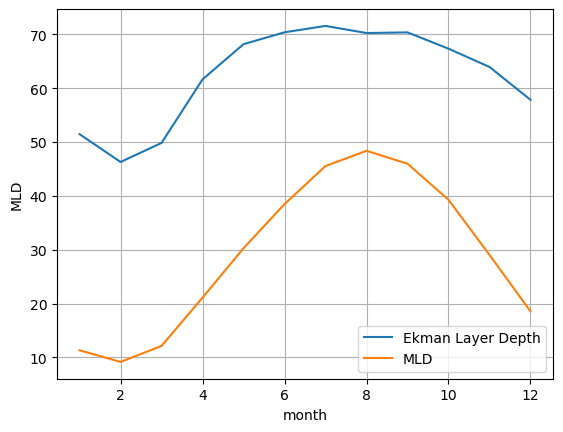

In [23]:
seasonality(out.Ek_layer_D).mean(dim=('coast_point','offshore')).plot(label='Ekman Layer Depth')
seasonality(MLD).mean(dim=('lon','lat')).plot(label='MLD')
plt.legend()
plt.grid(True)

/opt/conda/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2136: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contourf(x, y, z, **kwargs)
/opt/conda/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2136: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contourf(x, y, z, **kwargs)


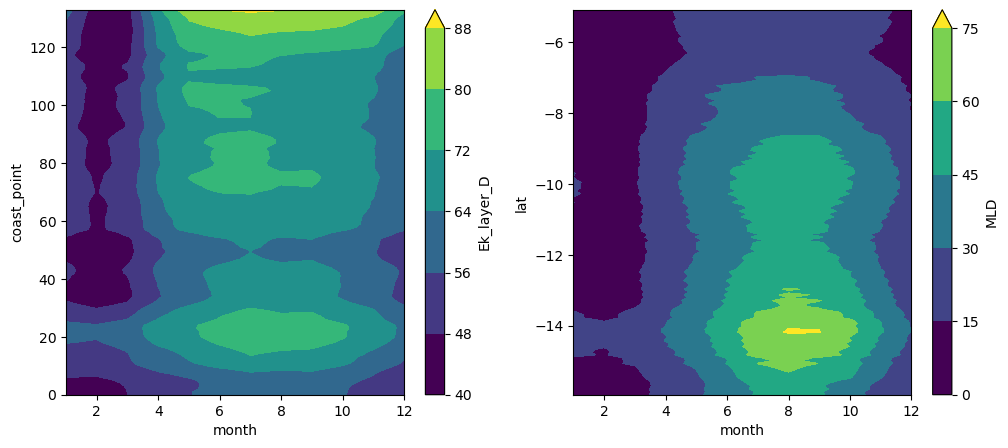

In [24]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

seasonality(out.Ek_layer_D).mean(dim=('offshore')).plot.contourf(x='month',label='Ekman Layer Depth',ax=ax[0],robust=True)
seasonality(MLD).mean(dim=('lon')).plot.contourf(x='month', label='MLD',ax=ax[1],robust=True)

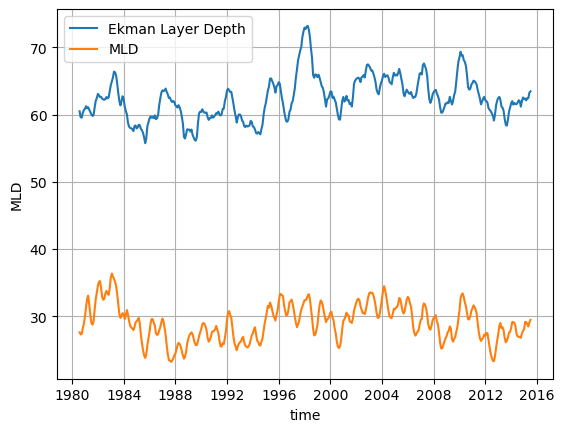

In [25]:
out.Ek_layer_D.mean(dim=('coast_point','offshore')).rolling(time=13,center=True).mean().plot(label='Ekman Layer Depth')
MLD.mean(dim=('lon','lat')).rolling(time=13,center=True).mean().plot(label='MLD')
plt.legend()
plt.grid(True)

/opt/conda/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2136: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contourf(x, y, z, **kwargs)


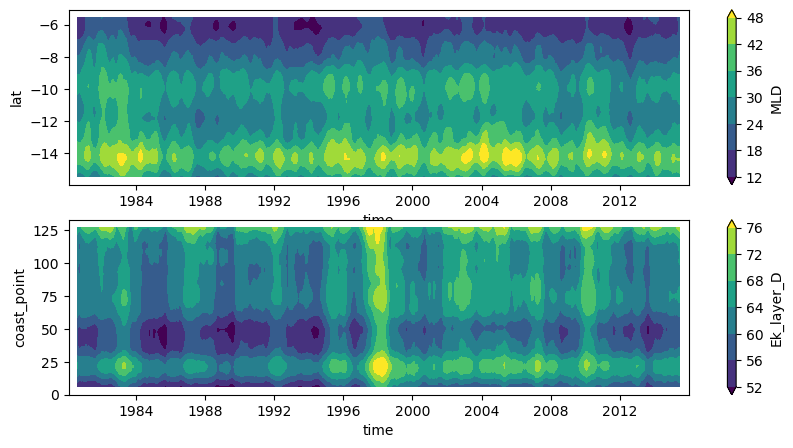

In [26]:
fig, ax = plt.subplots(2,1,figsize=(10,5))

MLD.mean('lon').rolling(time=13,center=True).mean().rolling(
    lat=13,center=True).mean().plot.contourf(x='time',ax=ax[0],robust=True)

out.Ek_layer_D.mean(dim=('offshore')).rolling(time=13,center=True).mean().rolling(
    coast_point=13,center=True).mean().plot.contourf(x='time',label='Ekman Layer Depth',ax=ax[1],robust=True)

* Stratification in the northern Peru is not taken into consideration by the Ekman layer depth, as this part usually recieves jet intrusions, influence of CTW. It is more evident during EN

In [24]:
# # ============================================================
# # 8. Ekman layer depth
# # ============================================================

# # latitude in radians
# lat_rad = np.deg2rad(latc)   # (coast, n)

# # avoid division by zero near equator
# sinlat = np.sin(lat_rad)
# sinlat_abs = np.abs(sinlat)

# # optional: avoid extremely small values (numerical stability)
# sinlat_abs[sinlat_abs < 1e-6] = np.nan

# # Ekman depth (meters)
# DE = 4.3 * windspeed / np.sqrt(sinlat_abs)   # (time, coast, n)